# Hey Kagglers!! Lets dive into the "fancy" NLP world with a simple yet illustrative problem

**As always ... Lets get our tool ready before we get started!**

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        
import numpy as np 
import pandas as pd 
from keras.datasets import imdb
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.preprocessing.text import text_to_word_sequence
from keras.preprocessing.text import Tokenizer  
from nltk.tokenize import word_tokenize
from keras.preprocessing.sequence import pad_sequences
from keras import models
import string
import seaborn as sns
from nltk.stem.porter import PorterStemmer
from keras import layers
from keras import losses
from keras import metrics
import html
from tensorflow.keras import optimizers
import nltk
nltk.download('punkt')
from nltk.corpus import stopwords
nltk.download('stopwords')
import re
from nltk.tokenize.casual import TweetTokenizer
from tensorflow.keras.utils import plot_model
import unicodedata

/kaggle/input/nlp-getting-started/sample_submission.csv
/kaggle/input/nlp-getting-started/train.csv
/kaggle/input/nlp-getting-started/test.csv
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Loading data set

In [2]:
train_df=pd.read_csv('../input/nlp-getting-started/train.csv')
test_df=pd.read_csv('../input/nlp-getting-started/test.csv')

In [3]:
train_df.head(20)

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
5,8,NaN,NaN,#RockyFire Update => California Hwy. 20 closed...,1
6,10,NaN,NaN,#flood #disaster Heavy rain causes flash flood...,1
7,13,NaN,NaN,I'm on top of the hill and I can see a fire in...,1
8,14,NaN,NaN,There's an emergency evacuation happening now ...,1
9,15,NaN,NaN,I'm afraid that the tornado is coming to our a...,1


*As we can see, the text needs alot of preprocessing to remove all unwanted and misleading parts*

In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


**For now ... we are going to stick only with the text and ignore the other features**

In [5]:
train_df.drop(['id','keyword','location'],axis = 1, inplace = True)
#we will need the test id column later for results submision 
test_id = test_df['id']
test_df.drop(['id','keyword','location'], axis = 1 , inplace = True)

In [6]:
train_df.head()

,text,target
0,Our Deeds are the Reason of this #earthquake M...,1
1,Forest fire near La Ronge Sask. Canada,1
2,All residents asked to 'shelter in place' are ...,1
3,"13,000 people receive #wildfires evacuation or...",1
4,Just got sent this photo from Ruby #Alaska as ...,1


## EDA

**Lets take a quick look at the distribution of the target**

In [7]:
train_df['target'].value_counts()

0    4342
1    3271
Name: target, dtype: int64

<AxesSubplot:title={'center':'Percent of disaster-related tweets'}, ylabel='target'>

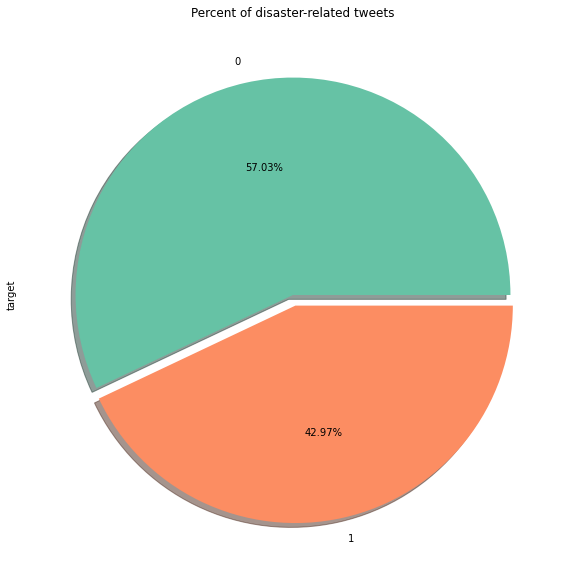

In [8]:
colors = sns.color_palette('Set2')

plt.figure(figsize=(10,10))
plt.title('Percent of disaster-related tweets')
explode = (0, 0.05)
train_df['target'].value_counts().plot.pie(shadow = True,colors = colors,explode = explode,autopct='%.2f%%')

### Number of characters in tweets

In [9]:
tweet = train_df

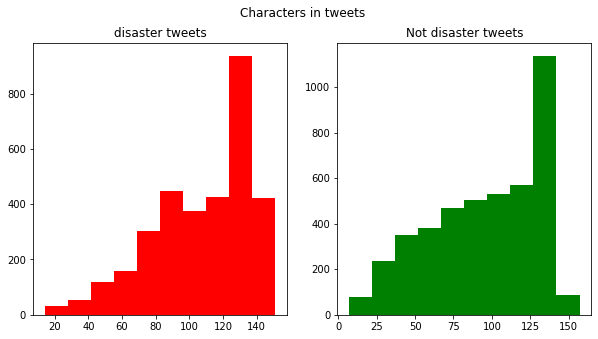

In [10]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,5))
tweet_len=tweet[tweet['target']==1]['text'].str.len()
ax1.hist(tweet_len,color='red')
ax1.set_title('disaster tweets')
tweet_len=tweet[tweet['target']==0]['text'].str.len()
ax2.hist(tweet_len,color='green')
ax2.set_title('Not disaster tweets')
fig.suptitle('Characters in tweets')
plt.show()

### Average word length in a tweet

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


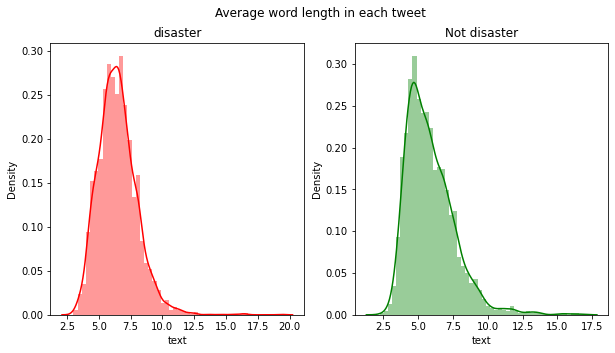

In [11]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,5))
word=tweet[tweet['target']==1]['text'].str.split().apply(lambda x : [len(i) for i in x])
sns.distplot(word.map(lambda x: np.mean(x)),ax=ax1,color='red')
ax1.set_title('disaster')
word=tweet[tweet['target']==0]['text'].str.split().apply(lambda x : [len(i) for i in x])
sns.distplot(word.map(lambda x: np.mean(x)),ax=ax2,color='green')
ax2.set_title('Not disaster')
fig.suptitle('Average word length in each tweet');

 Now lets make the necessary preprocessing to get the data ready for modeling

## Text Preprocessing

## All preprocessing functions used

In [12]:
def remove_special_chars(text):
    re1 = re.compile(r'  +')
    x1 = text.lower().replace('#39;', "'").replace('amp;', '&').replace('#146;', "'").replace(
        'nbsp;', ' ').replace('#36;', '$').replace('\\n', "\n").replace('quot;', "'").replace(
        '<br />', "\n").replace('\\"', '"').replace('<unk>', 'u_n').replace(' @.@ ', '.').replace(
        ' @-@ ', '-').replace('\\', ' \\ ').replace('.*', '.').replace('#', '')
    return re1.sub(' ', html.unescape(x1))

def to_lowercase(text):
    return text.lower()

def replace_numbers(text):
    """Replace all interger occurrences in list of tokenized words with textual representation"""
    return re.sub(r'\d+', '', text)

def remove_non_ascii(text):
    """Remove non-ASCII characters from list of tokenized words"""
    return unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore')

def sequencing(text):
    t = TweetTokenizer(preserve_case=False,strip_handles=True, reduce_len=True)
    seq=t.tokenize(text)
    return seq

def remove_punct(seq):
    words = [w for w in seq if w not in string.punctuation[1:]] #remove all punc excluding exlimnation mark
    return words

def stop_words_remove(seq):
    stop_words = stopwords.words('english')
    words = [w for w in seq if w not in stop_words]
    return words

# lemmetization

def lemmatize_words(words):
    """Lemmatize words in text"""

    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(word) for word in words]

def lemmatize_verbs(words):
    """Lemmatize verbs in text"""

    lemmatizer = WordNetLemmatizer()
    return ' '.join([lemmatizer.lemmatize(word, pos='v') for word in words])

#join all
def list_text(words):
    return ''.join(words)

URL_remover = lambda x: re.sub(r'http\S+', '', x)

def normalize_text( text):
    text = remove_special_chars(text)
    text = remove_non_ascii(text)
    text = to_lowercase(text)
    text = replace_numbers(text)
    text = URL_remover(text)
    words = sequencing(text)
    words = remove_punct(words)
    words = stop_words_remove(words)
    words=lemmatize_words(words)
    words=lemmatize_verbs(words)
    words=list_text(words)
    return words

def normalize_corpus(corpus):
      return [normalize_text(t) for t in corpus]

In [13]:
corpus_train=normalize_corpus(list(train_df.text))
corpus_test=normalize_corpus(list(test_df.text))


In [14]:
corpus_train[:10]

['deed reason earthquake may allah forgive u',
 'forest fire near la ronge sask canada',
 'resident ask shelter place notify officer evacuation shelter place order expect',
 'people receive wildfire evacuation order california',
 'get send photo ruby alaska smoke wildfire pour school',
 'rockyfire update california hwy close direction due lake county fire cafire wildfire',
 'flood disaster heavy rain cause flash flood street manitou colorado spring area',
 "i'm top hill see fire wood ...",
 "there's emergency evacuation happen build across street",
 "i'm afraid tornado come area ..."]

## Tokenizer

**Tokenization is essentially splitting a phrase, sentence, paragraph, or an entire text document into smaller units, such as individual words or terms**

In [15]:
from keras.preprocessing.text import Tokenizer
tok = Tokenizer(oov_token='UNK')
texts=corpus_train
tok.fit_on_texts(texts)

In [16]:
#token dictionary
tok.word_index

{'UNK': 1,
 'get': 2,
 'like': 3,
 'fire': 4,
 'u': 5,
 'go': 6,
 "i'm": 7,
 'bomb': 8,
 'new': 9,
 'via': 10,
 'one': 11,
 'say': 12,
 'news': 13,
 'people': 14,
 'burn': 15,
 'time': 16,
 'kill': 17,
 'year': 18,
 'video': 19,
 'make': 20,
 'flood': 21,
 'crash': 22,
 'disaster': 23,
 'come': 24,
 'emergency': 25,
 'build': 26,
 'attack': 27,
 'body': 28,
 'see': 29,
 'day': 30,
 'look': 31,
 'home': 32,
 'police': 33,
 'think': 34,
 'take': 35,
 'know': 36,
 'would': 37,
 'family': 38,
 'life': 39,
 'still': 40,
 'train': 41,
 'storm': 42,
 'love': 43,
 'back': 44,
 'suicide': 45,
 'watch': 46,
 'want': 47,
 'california': 48,
 'scream': 49,
 'collapse': 50,
 'car': 51,
 'world': 52,
 'bag': 53,
 'man': 54,
 'death': 55,
 'work': 56,
 'rt': 57,
 'first': 58,
 'cause': 59,
 'two': 60,
 'nuclear': 61,
 'need': 62,
 'drown': 63,
 'war': 64,
 'wreck': 65,
 'dead': 66,
 'accident': 67,
 'destroy': 68,
 'w': 69,
 'plan': 70,
 'wind': 71,
 'full': 72,
 'feel': 73,
 'hiroshima': 74,
 'today'

In [17]:
# about 12k unique words and others extracted
len(tok.word_index.keys())

12119

## *Text features*
### So far, we have tranformed the text into binary/digital form that can be understood by ML models.
### However, we can further apply or extract different features from the vectorized form.
#### In other words, we can represent the sequence of word indices we obtained in different forms.

## BoW with keras tokenizer
> 3 BoW models for the following features:
> - Binary       (default, is word present or not)
> - Count + Freq (count of each word in text)
> - TF-IDF       (frequency-inverse scoring for each word) 

In [18]:
bow = tok.texts_to_matrix(texts[:10], mode='count')
bow.shape

(10, 12120)

In [19]:
#simple illustration for bow
bow

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

# 1. Binary

In [20]:
x_binary = tok.texts_to_matrix(texts, mode='binary')
y_binary = train_df['target']
x_binary.shape , x_binary.shape[0]

((7613, 12120), 7613)

In [21]:
x_train, x_val, y_train, y_val = train_test_split(x_binary, y_binary, test_size=0.4, random_state=42)

In [22]:
import tensorflow as tf

In [23]:
tf.keras.backend.clear_session()
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(x_binary.shape[1],)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer=optimizers.RMSprop(lr=0.001),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])
			  
history = model.fit(x_train,
                    y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))
history_dict = history.history
history_dict.keys()

2022-04-12 13:37:35.872110: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.
/opt/conda/lib/python3.7/site-packages/keras/optimizer_v2/optimizer_v2.py:356: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  "The `lr` argument is deprecated, use `learning_rate` instead.")
2022-04-12 13:37:36.354567: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Epoch 1/20
9/9 [==============================] - 1s 75ms/step - loss: 0.6886 - binary_accuracy: 0.6413 - val_loss: 0.6802 - val_binary_accuracy: 0.7574
Epoch 2/20
9/9 [==============================] - 0s 22ms/step - loss: 0.6645 - binary_accuracy: 0.8487 - val_loss: 0.6589 - val_binary_accuracy: 0.7689
Epoch 3/20
9/9 [==============================] - 0s 20ms/step - loss: 0.6306 - binary_accuracy: 0.8748 - val_loss: 0.6334 - val_binary_accuracy: 0.7702
Epoch 4/20
9/9 [==============================] - 0s 21ms/step - loss: 0.5917 - binary_accuracy: 0.8879 - val_loss: 0.6080 - val_binary_accuracy: 0.7718
Epoch 5/20
9/9 [==============================] - 0s 21ms/step - loss: 0.5519 - binary_accuracy: 0.8966 - val_loss: 0.5848 - val_binary_accuracy: 0.7689
Epoch 6/20
9/9 [==============================] - 0s 20ms/step - loss: 0.5133 - binary_accuracy: 0.9043 - val_loss: 0.5631 - val_binary_accuracy: 0.7712
Epoch 7/20
9/9 [==============================] - 0s 22ms/step - loss: 0.4762 - bi

dict_keys(['loss', 'binary_accuracy', 'val_loss', 'val_binary_accuracy'])

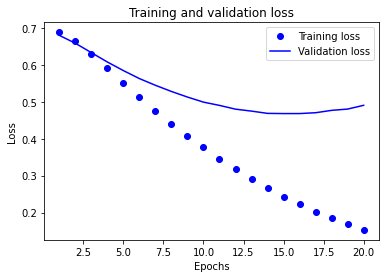

In [24]:

acc = history.history['binary_accuracy']
val_acc = history.history['val_binary_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

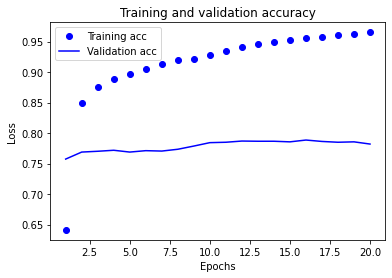

In [25]:
plt.clf()   # clear figure
acc_values = history_dict['binary_accuracy']
val_acc_values = history_dict['val_binary_accuracy']

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# 2- Count 

In [26]:
x_count = tok.texts_to_matrix(texts, mode='count')
y_count = train_df['target']
x_count.shape , x_count.shape[1]

((7613, 12120), 12120)

In [27]:
x_train, x_val, y_train, y_val = train_test_split(x_count, y_count, test_size=0.4, random_state=42)

In [28]:
tf.keras.backend.clear_session()
modelc = models.Sequential()
modelc.add(layers.Dense(16, activation='relu', input_shape=(x_binary.shape[1],)))
modelc.add(layers.Dense(16, activation='relu'))
modelc.add(layers.Dense(1, activation='sigmoid'))

modelc.compile(optimizer=optimizers.RMSprop(lr=0.001),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])
			  
history = modelc.fit(x_train,
                    y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))
history_dict = history.history
history_dict.keys()

Epoch 1/20
9/9 [==============================] - 1s 66ms/step - loss: 0.6761 - binary_accuracy: 0.6519 - val_loss: 0.6518 - val_binary_accuracy: 0.7292
Epoch 2/20
9/9 [==============================] - 0s 21ms/step - loss: 0.6182 - binary_accuracy: 0.8012 - val_loss: 0.6126 - val_binary_accuracy: 0.7827
Epoch 3/20
9/9 [==============================] - 0s 22ms/step - loss: 0.5615 - binary_accuracy: 0.8542 - val_loss: 0.5795 - val_binary_accuracy: 0.7942
Epoch 4/20
9/9 [==============================] - 0s 20ms/step - loss: 0.5091 - binary_accuracy: 0.8730 - val_loss: 0.5514 - val_binary_accuracy: 0.8040
Epoch 5/20
9/9 [==============================] - 0s 21ms/step - loss: 0.4598 - binary_accuracy: 0.8921 - val_loss: 0.5272 - val_binary_accuracy: 0.8083
Epoch 6/20
9/9 [==============================] - 0s 21ms/step - loss: 0.4140 - binary_accuracy: 0.9067 - val_loss: 0.5068 - val_binary_accuracy: 0.8086
Epoch 7/20
9/9 [==============================] - 0s 23ms/step - loss: 0.3717 - bi

dict_keys(['loss', 'binary_accuracy', 'val_loss', 'val_binary_accuracy'])

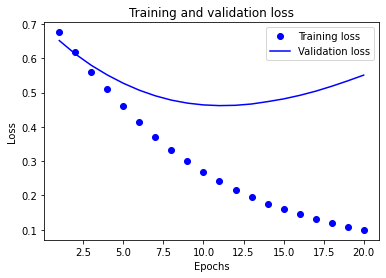

In [29]:
acc = history.history['binary_accuracy']
val_acc = history.history['val_binary_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

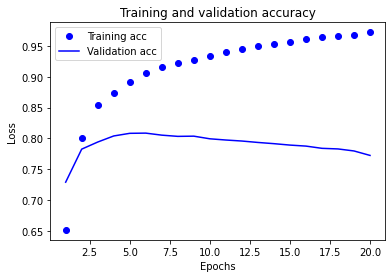

In [30]:
plt.clf()   # clear figure
acc_values = history_dict['binary_accuracy']
val_acc_values = history_dict['val_binary_accuracy']

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# 3- TF_IDF

In [31]:
x_idf = tok.texts_to_matrix(texts, mode='tfidf')
y_idf = train_df['target']
x_idf.shape , x_idf.shape[1]

((7613, 12120), 12120)

In [32]:
x_train, x_val, y_train, y_val = train_test_split(x_idf, y_idf, test_size=0.4, random_state=42)

In [33]:
from keras.layers import Dropout

In [34]:
tf.keras.backend.clear_session()
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(x_idf.shape[1],)))
#model.add(Dropout(0.2))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer=optimizers.RMSprop(lr=0.001),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])
			  
history = model.fit(x_train,
                    y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))
history_dict = history.history
history_dict.keys()

Epoch 1/20
9/9 [==============================] - 1s 60ms/step - loss: 0.6554 - binary_accuracy: 0.6637 - val_loss: 0.6119 - val_binary_accuracy: 0.7505
Epoch 2/20
9/9 [==============================] - 0s 23ms/step - loss: 0.5139 - binary_accuracy: 0.8603 - val_loss: 0.5426 - val_binary_accuracy: 0.7833
Epoch 3/20
9/9 [==============================] - 0s 22ms/step - loss: 0.3964 - binary_accuracy: 0.9017 - val_loss: 0.5012 - val_binary_accuracy: 0.7866
Epoch 4/20
9/9 [==============================] - 0s 20ms/step - loss: 0.3092 - binary_accuracy: 0.9240 - val_loss: 0.4813 - val_binary_accuracy: 0.7879
Epoch 5/20
9/9 [==============================] - 0s 20ms/step - loss: 0.2455 - binary_accuracy: 0.9453 - val_loss: 0.4762 - val_binary_accuracy: 0.7866
Epoch 6/20
9/9 [==============================] - 0s 20ms/step - loss: 0.1982 - binary_accuracy: 0.9569 - val_loss: 0.4808 - val_binary_accuracy: 0.7889
Epoch 7/20
9/9 [==============================] - 0s 21ms/step - loss: 0.1615 - bi

dict_keys(['loss', 'binary_accuracy', 'val_loss', 'val_binary_accuracy'])

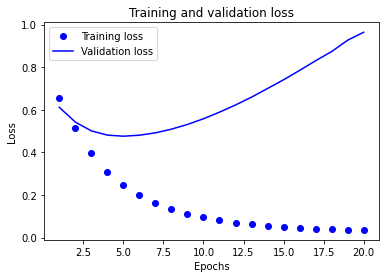

In [35]:
acc = history.history['binary_accuracy']
val_acc = history.history['val_binary_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

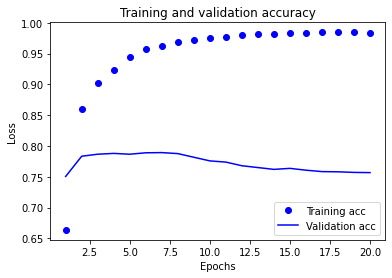

In [36]:
plt.clf()   # clear figure
acc_values = history_dict['binary_accuracy']
val_acc_values = history_dict['val_binary_accuracy']

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

> TF-IDF not normalized?
> 
> In the above setting, TFIDF in keras texts_to_matrix produce non normalized values. This is because the IDF ~= 1/DF, but log(1+DF)
> For this bug, it's better to use sklearn TfidfVectorizer

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=10000)
vectorizer.fit(texts)


x_idf = vectorizer.transform(texts)

import scipy 
x_idf =scipy.sparse.csr_matrix.todense(x_idf)


y_idf = train_df['target']
x_idf.shape , x_idf.shape[1]

((7613, 10000), 10000)

In [38]:
x_train, x_val, y_train, y_val = train_test_split(x_idf, y_idf, test_size=0.4, random_state=42)

In [39]:
tf.keras.backend.clear_session()
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(x_idf.shape[1],)))
#model.add(Dropout(0.2))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer=optimizers.RMSprop(lr=0.001),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])
			  
history = model.fit(x_train,
                    y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))
history_dict = history.history
history_dict.keys()

Epoch 1/20
9/9 [==============================] - 1s 57ms/step - loss: 0.6857 - binary_accuracy: 0.5682 - val_loss: 0.6765 - val_binary_accuracy: 0.5903
Epoch 2/20
9/9 [==============================] - 0s 19ms/step - loss: 0.6637 - binary_accuracy: 0.6302 - val_loss: 0.6597 - val_binary_accuracy: 0.6615
Epoch 3/20
9/9 [==============================] - 0s 18ms/step - loss: 0.6393 - binary_accuracy: 0.7182 - val_loss: 0.6427 - val_binary_accuracy: 0.6921
Epoch 4/20
9/9 [==============================] - 0s 18ms/step - loss: 0.6142 - binary_accuracy: 0.7591 - val_loss: 0.6266 - val_binary_accuracy: 0.7278
Epoch 5/20
9/9 [==============================] - 0s 18ms/step - loss: 0.5885 - binary_accuracy: 0.7979 - val_loss: 0.6102 - val_binary_accuracy: 0.7328
Epoch 6/20
9/9 [==============================] - 0s 19ms/step - loss: 0.5620 - binary_accuracy: 0.8174 - val_loss: 0.5944 - val_binary_accuracy: 0.7475
Epoch 7/20
9/9 [==============================] - 0s 18ms/step - loss: 0.5348 - bi

dict_keys(['loss', 'binary_accuracy', 'val_loss', 'val_binary_accuracy'])

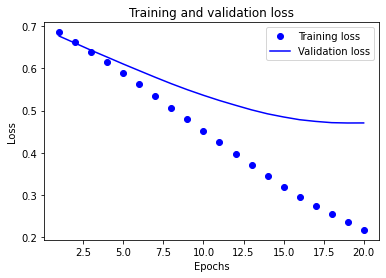

In [40]:
acc = history.history['binary_accuracy']
val_acc = history.history['val_binary_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

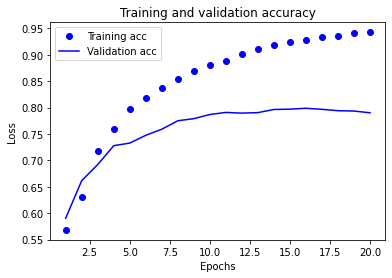

In [41]:
plt.clf()   # clear figure
acc_values = history_dict['binary_accuracy']
val_acc_values = history_dict['val_binary_accuracy']

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

### As we can see, the count bow model preformed best for the same NN dense model with the highest accuracy ; howerver the freq idf was least to overfit!

In [42]:
#submit

In [43]:
x_test = tok.texts_to_matrix(corpus_test, mode='count')
s=np.array(modelc.predict(x_test)>0.5).astype('int')
subm=pd.DataFrame(test_id ,columns=['id'])
subm['target']=s

In [44]:
subm.to_csv('submission1.csv',index=False)